# HBank - Simple - Gertler Karadi


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sequence_jacobian import simple, solved, combine, create_model  # functions
from sequence_jacobian import grids, hetblocks                       # modules

In [2]:
calibration_start = {

    #==> Household parameters
    'frisch': 0.5,
    'eis': 0.5,
    'habit': 0.00,
    'C_lag': 0.0,


    #==> Assets
    'rb': 0.00,                                 # Real return on liquid assets 
    'ra': 0.01,                                 # Real return on illiquid assets. 
    "B_sum" :  2.4,                             # Liquid market-clearing target
    "b_gov":  2.4,                              # Government bond supply 0.6*4
    "A_target" :  (3-1)*0.75*4,                          # HH illiquid market-clearing target
    "A_sum" :  (4-1)*0.75*4,                          # HH illiquid market-clearing target

    "B_target" :  2.4,                                    # HH liquid market-clearing target
    'chi2': 2.000,                              # Curvature of the portfolio adjustment cost


    #==> Policy parameters
    'T': 0.15,                                  # Tax rate on labour income
    'phi_T'    : 0.06,   # slow adjustment: ~33 quarters to halve the debt gap



    ##==> Aggregate targets
    "Y":       1.00,                                    # Output (normalised to 1)
    "N":       1.0,                                     # Aggregate labour supply
    'w': 0.7,
    'N': 1.0,


    ##==> Financial intermediary parameters
    'f': 0.06,
    'lambda_gk': 0.116,
    'ksi': 0.5,
    "n_inter": 0.75 * 4,                                # Bank net worth (data)
    "theta":   4,                                       # Bank leverage = K / n_inter (data)


    #==> Production Function paramters
    'alpha': 0.35,                                    # Capital share in production
    'delta': 0.0125,                                  # Depreciation rate of capital


    #==> Discretisation parameters
    'nZ': 19,
    'nB': 40,           
    'nA': 30,
    'nK': 30,
    'bmax': 250,
    'amax': 1200,
    'kmax': 1,


    #==> Not used (unless nZ =/=19): 
    'rho_z': 0.9,                  # persistance of the income shock
    'sigma_z': 0.1,                # standard deviation of the income shock
}

calibration_hh = {
    **calibration_start,   # Load exisiting parameters from calibration_start

    #==> Calibrated by solve_chi
    'chi0': 0.176337,      # Calibration guess (see solve_chi)
    'chi1': 19.886470,     # Calibration guess (see solve_chi)
    'beta': 0.986,          # Calibration guess (see solve_chi)   

    #==> Steady state value given other parameters 
    'div': 0.11,          # Dividend payout ratio - from steady state value of the dividend payout ratio in the model

}



In [3]:
### Single HH
from numba import guvectorize
from sequence_jacobian.blocks.het_block import het
from sequence_jacobian import interpolate
import scipy.linalg

# External habit formation:
HABIT_CONS_FLOOR = 1e-8


def surplus_consumption(c, habit, C_lag):
    return np.maximum(c - habit * C_lag, HABIT_CONS_FLOOR)


def hh_init(b_grid, a_grid, z_grid, eis, habit, C_lag):
    # IMPORTANT: Va and Vb are marginal values, so their initial guess must be
    # based on surplus consumption ce, not actual consumption c.  The old
    # no-habit guesses are therefore interpreted as ce guesses.  Subtracting
    # habit*C_lag here makes low-grid states start with almost infinite marginal
    # utility and can prevent policy-function convergence.
    ce_guess_a = np.maximum(0.6 + 1.1 * b_grid[:, np.newaxis] + a_grid, HABIT_CONS_FLOOR)
    ce_guess_b = np.maximum(0.5 + b_grid[:, np.newaxis] + 1.2 * a_grid, HABIT_CONS_FLOOR)
    Va = ce_guess_a ** (-1 / eis) * np.ones((z_grid.shape[0], 1, 1))
    Vb = ce_guess_b ** (-1 / eis) * np.ones((z_grid.shape[0], 1, 1))
    return Va, Vb


def adjustment_costs(a, a_grid, ra, chi0, chi1, chi2):
    adj_cost = get_Psi_and_deriv(a, a_grid, ra, chi0, chi1, chi2)[0]
    return adj_cost


def marginal_cost_grid(a_grid, ra, chi0, chi1, chi2):
    Psi1 = get_Psi_and_deriv(a_grid[:, np.newaxis],
                             a_grid[np.newaxis, :], ra, chi0, chi1, chi2)[1]
    return Psi1


@het(exogenous='Pi', policy=['b', 'a'], backward=['Vb', 'Va'],
     hetinputs=[marginal_cost_grid], hetoutputs=[adjustment_costs], backward_init=hh_init)
def hh(Va_p, Vb_p, a_grid, b_grid, z_grid, e_grid, k_grid, beta, eis, habit, C_lag,
       rb, ra, chi0, chi1, chi2, Psi1):
    habit_stock = habit * C_lag

    Wb = beta * Vb_p
    Wa = beta * Va_p
    W_ratio = Wa / Wb

    i, pi = lhs_equals_rhs_interpolate(W_ratio, 1 + Psi1)
    a_endo_unc = interpolate.apply_coord(i, pi, a_grid)
    ce_endo_unc = interpolate.apply_coord(i, pi, Wb) ** (-eis)
    c_endo_unc = ce_endo_unc + habit_stock

    b_endo = (c_endo_unc + a_endo_unc + addouter(-z_grid, b_grid, -(1 + ra) * a_grid)
              + get_Psi_and_deriv(a_endo_unc, a_grid, ra, chi0, chi1, chi2)[0]) / (1 + rb)

    i, pi = interpolate.interpolate_coord(b_endo.swapaxes(1, 2), b_grid)
    a_unc = interpolate.apply_coord(i, pi, a_endo_unc.swapaxes(1, 2)).swapaxes(1, 2)
    b_unc = interpolate.apply_coord(i, pi, b_grid).swapaxes(1, 2)

    lhs_con = W_ratio[:, 0:1, :] / (1 + k_grid[np.newaxis, :, np.newaxis])
    i, pi = lhs_equals_rhs_interpolate(lhs_con, 1 + Psi1)
    a_endo_con = interpolate.apply_coord(i, pi, a_grid)
    ce_endo_con = ((1 + k_grid[np.newaxis, :, np.newaxis]) ** (-eis)
                   * interpolate.apply_coord(i, pi, Wb[:, 0:1, :]) ** (-eis))
    c_endo_con = ce_endo_con + habit_stock

    b_endo = (c_endo_con + a_endo_con
              + addouter(-z_grid, np.full(len(k_grid), b_grid[0]), -(1 + ra) * a_grid)
              + get_Psi_and_deriv(a_endo_con, a_grid, ra, chi0, chi1, chi2)[0]) / (1 + rb)

    a_con = interpolate.interpolate_y(b_endo.swapaxes(1, 2), b_grid,
                                      a_endo_con.swapaxes(1, 2)).swapaxes(1, 2)

    a, b = a_unc.copy(), b_unc.copy()
    b[b <= b_grid[0]] = b_grid[0]
    a[b <= b_grid[0]] = a_con[b <= b_grid[0]]

    Psi, _, Psi2 = get_Psi_and_deriv(a, a_grid, ra, chi0, chi1, chi2)

    c = addouter(z_grid, (1 + rb) * b_grid, (1 + ra) * a_grid) - Psi - a - b
    ce = surplus_consumption(c, habit, C_lag)
    uc = ce ** (-1 / eis)
    uce = e_grid[:, np.newaxis, np.newaxis] * uc

    Va = (1 + ra - Psi2) * uc
    Vb = (1 + rb) * uc

    return Va, Vb, a, b, c, ce, uc, uce



def get_Psi_and_deriv(ap, a, ra, chi0, chi1, chi2):
    a_with_return = (1 + ra) * a
    a_change = ap - a_with_return
    abs_a_change = np.abs(a_change)
    sign_change = np.sign(a_change)

    adj_denominator = a + chi0
    Psi = chi1 / chi2 * (abs_a_change / adj_denominator) ** (chi2) * adj_denominator
    Psi1 = chi1 * sign_change * abs_a_change ** (chi2 - 1) * adj_denominator ** (1 - chi2)
    Psi2 = (-(1 + ra) * Psi1
            - chi1 * abs_a_change ** (chi2) * adj_denominator ** (-chi2 - 1) * adj_denominator
            + chi1 / chi2 * (abs_a_change / adj_denominator) ** (chi2))

    return Psi, Psi1, Psi2



def matrix_times_first_dim(A, X):
    return (A @ X.reshape(X.shape[0], -1)).reshape(X.shape)



def addouter(z, b, a):
    return z[:, np.newaxis, np.newaxis] + b[:, np.newaxis] + a



@guvectorize(['void(float64[:], float64[:,:], uint32[:], float64[:])'], '(ni),(ni,nj)->(nj),(nj)')
def lhs_equals_rhs_interpolate(lhs, rhs, iout, piout):
    ni, nj = rhs.shape
    assert len(lhs) == ni
    i = 0
    for j in range(nj):
        while True:
            if lhs[i] < rhs[i, j]:
                break
            elif i < nj - 1:
                i += 1
            else:
                break
        if i == 0:
            iout[j] = 0
            piout[j] = 1
        else:
            iout[j] = i - 1
            err_upper = rhs[i, j] - lhs[i]
            err_lower = rhs[i - 1, j] - lhs[i - 1]
            piout[j] = err_upper / (err_upper - err_lower)


In [4]:
import sys
from pathlib import Path

_routines = Path.cwd() / "routines"
if str(_routines) not in sys.path:
    sys.path.insert(0, str(_routines))

from grids      import make_grids_1   as make_grids
from income     import income_hbfed   as income   # simple linear tax: z = ((1-alpha)*Y - T) * e
from calculate_gini import hh_inner, calculate_gini

ModuleNotFoundError: No module named 'grids'

In [ ]:
hh_ext = hh.add_hetinputs([income, make_grids])
hh_ext = hh_ext.add_hetoutputs([hh_inner])

In [ ]:
def solve_with_habit_fixed_point(model, calibration, unknowns=None, targets=None,
                                 tol=1e-5, max_iter=200, relax=0.99,
                                 verbose=False, **solve_kwargs):
    cal = dict(calibration)  # always a plain dict, even if calibration is SteadyStateDict
    if 'habit' not in cal:
        cal['habit'] = 0.6
    if 'C_lag' not in cal:
        cal['C_lag'] = 0.0

    unknowns_iter = unknowns.copy() if isinstance(unknowns, dict) else unknowns

    for it in range(max_iter):
        C_old = float(cal['C_lag'])   # outer-loop anchor — never overwritten inside retry

        for attempt in range(12):
            try:
                if unknowns_iter is None and targets is None:
                    ss = model.steady_state(cal)
                else:
                    ss = model.solve_steady_state(cal, unknowns_iter, targets, **solve_kwargs)
                break
            except ValueError as exc:
                if 'No convergence of policy functions' not in str(exc) or abs(float(cal['C_lag'])) < 1e-12:
                    raise
                cal['C_lag'] = 0.5 * float(cal['C_lag'])
                if verbose:
                    print(f"  retry {attempt+1}: C_lag halved to {cal['C_lag']:.6g}")
        else:
            raise RuntimeError('Could not find a feasible C_lag for the household policy iteration.')

        C_lag_solved = float(cal['C_lag'])   # actual solve point (may be < C_old after retry)
        C_new = float(ss['C'])
        err = C_new - C_old

        if verbose:
            print(f"habit fp iter {it:03d}: C_lag={C_old:.12g}, C={C_new:.12g}, err={err:.3e}")

        if isinstance(unknowns_iter, dict):
            unknowns_iter = unknowns_iter.copy()
            for key in unknowns_iter:
                if key in ss:
                    unknowns_iter[key] = float(ss[key])

        # Convergence check: only valid when C was evaluated at C_old (no retry fired).
        # If the retry fired, C_lag_solved != C_old, so `err` is not the residual at C_old.
        retry_fired = C_lag_solved < C_old - 1e-12
        if not retry_fired and abs(err) <= tol * max(1.0, abs(C_new)):
            cal['C_lag'] = C_new
            try:
                ss['C_lag'] = C_new
                ss['habit'] = cal['habit']
            except Exception:
                pass
            return ss, cal

        # Update: take a damped step from C_lag_solved (the last valid evaluation point)
        # toward C_new.  Using C_old as the base when the retry fired would propose a
        # C_lag beyond C_lag_solved, immediately re-triggering the policy failure.
        base = C_lag_solved if retry_fired else C_old
        cal['C_lag'] = base + relax * (C_new - base)

    raise RuntimeError(f"External-habit fixed point did not converge after {max_iter} iterations. Last err={err:.3e}")

### Household side: calibrate the inital guess of the portfolio costs 

In [ ]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd() / "Steady_state_finder"))

from solve_chi import solve_chi


blocks = [hh_ext]
hank_hh = create_model(blocks, name='Two-Asset HANK HH')
#calibration_hh, ssh = solve_chi(hank_hh, calibration_hh, calibration_hh['A_target'], calibration_hh['B_target']) # Optional calibration step to solve for chi0 and chi1 given targets on A and B

## Equations

### Steady State Equations

In [ ]:
# Steady State Equations
@simple 
def smart_steady(A_sum, B_sum, theta, Y, T, n_inter, rb, ra, alpha, delta, f, N):
    K       = A_sum + n_inter                        # Eq Total capital = HH illiquid + bank equity
    rk      = alpha * Y / K - delta                  # Return on capital (Cobb-Douglas, Q=1 in SS)
    rn      = theta * (rk - ra) + ra                 # Bank equity return (internal only)
    m       = n_inter * (1 - (1 - f) * (1 + rn))     # Transfer to new bankers
    k_inter = K                                      # Bank holds all capital
    I       = K * delta                              # SS investment
    b_gov   = B_sum                                  # Liquid = only government bonds
    G       = T - rb * b_gov                         # Government spending (residual)
    Z       = Y / K ** alpha * N ** (1 - alpha)      # TFP to match Y=1
    rb_ante = rb                                     # Constant return on bonds
    return K, rk, m, k_inter, I, b_gov, G, Z, rb_ante

@simple
def market_clearing(Y, C, ADJ_COST, I, G, B_sum, B, A_sum, A,):
    goods_mkt    = Y - C - ADJ_COST  - I - G               # Y=C+I+G+ADJ+Consumption of Bankers  CHECK
    liquid_mkt   = B_sum - B                               # Liquid market clearing
    illiquid_mkt = A_sum - A                               # Illiquid market clearing
    return goods_mkt, liquid_mkt, illiquid_mkt

@simple
def steady_auxilliary(theta, rk, ra, delta, alpha, Y, K, N, lambda_gk, beta, ksi):
    iota  = delta                                    # Investment I/K ratio equal to depreciation in ss
    mpk   = alpha * (Y / K)                          # Marginal Product of capital (from Cobb-Douglas)
    rn    = theta * (rk - ra) + ra                   # sole SSJ provider of rn CHECK
    w     = (1 - alpha) * Y / N                      # Wage from Cobb-Douglas

    # In SS the SDF equals the household beta (UCE_{t+1}/UCE_t = 1)
    Omega = theta * lambda_gk / (beta * (1 + rn))
    nu    = beta * Omega * (rk - ra)
    eta   = beta * Omega * (1 + ra)

    gamma0 = delta**ksi / (1 - ksi)                 #Jerman (1998) - in steady state with I/K=delta -> Q=1 that is phi'(delta)=1
    gamma1 = -delta * ksi / (1 - ksi)               #Jerman (1998) - in steady state phi(delta)=delta
    return iota, mpk, rn, w, Omega, nu, eta, gamma0, gamma1


@simple
def banker_div(rn, n_inter):
    div = rn * n_inter    # return on bank equity to the households 
    return div

### Off steady state equations

In [ ]:
@simple
def capital_adj(Y, K, Q, I, alpha, delta, gamma0, gamma1, ksi):
    iota        = I / K(-1)
    mpk         = alpha * Y / K(-1)
    rk          = (mpk + (1 - delta) * Q) / Q(-1) - 1
    q_res       = Q - 1 / (gamma0 * (1 - ksi) * iota ** (-ksi))
    capital_res = K - (1 - delta) * K(-1) - (gamma0 * iota ** (1 - ksi) + gamma1) * K(-1)
    return iota, mpk, rk, q_res, capital_res

@simple
def intermediation_IC(nu, eta, lambda_gk):
    theta = eta / (lambda_gk - nu)
    return theta

@simple
def bank_return(theta, rk, ra):
    rn = theta(-1) * (rk - ra) + ra
    return rn

@simple
def sdf(beta, UCE):
    SDF = beta * UCE(+1) / UCE
    return SDF

@simple
def intermediation_P1(rk, ra, nu, lambda_gk, eta, theta, n_inter, SDF, f):
    Omega_p1 = f + (1 - f) * lambda_gk * theta(+1)
    nu_res  = nu  - SDF * Omega_p1 * (rk(+1) - ra(+1))
    eta_res = eta - SDF * Omega_p1 * (1 + ra(+1))
    k_inter = theta * n_inter
    return nu_res, eta_res, k_inter

@simple
def intermediation_P2(rn, n_inter, m, f):
    n_inter_val = (1 - f) * (1 + rn) * n_inter(-1) + m - n_inter
    return n_inter_val

@simple
def intermediation_P3(theta, n_inter, b_gov):
    A_sum = (theta - 1) * n_inter
    B_sum = b_gov
    return A_sum, B_sum

@simple
def government(T, rb, b_gov):
    G = T - (1 + rb) * b_gov(-1) + b_gov
    return G

@simple
def mon_pol(rb_ante):
    rb = rb_ante(-1)
    return rb

@simple
def government_dynamic(G, rb, b_gov):
    T = G + (1 + rb) * b_gov(-1) - b_gov
    return T

@simple
def fiscal(b_gov, T_ss, b_gov_ss, phi_T, G, rb):
    # Tax rule + government budget constraint combined in one block so that
    # b_gov can be the *unknown* of a solved block.  This avoids the cycle
    # that arises when tax_rule and gov_budget are separate: SSJ reads
    # function *signatures* for the dependency graph, so a separate tax_rule
    # with b_gov in its signature would appear to need the current b_gov that
    # gov_budget_solved produces, creating a cycle.  With b_gov as the unknown
    # here, SSJ treats it as an output and only needs b_gov(-1) (predetermined).
    #
    # Tax rule:  T = T_ss + phi_T*(b_gov(-1) - b_gov_ss)
    # Budget:    b_gov = (1+rb)*b_gov(-1) + G - T  →  b_gov_res = 0
    T        = T_ss + phi_T * (b_gov(-1) - b_gov_ss)
    b_gov_res = (1 + rb) * b_gov(-1) + G - T - b_gov
    return T, b_gov_res

@simple
def rk_from_production(Y, K, alpha, delta):
    rk = alpha * Y / K - delta
    return rk

@simple
def habit_law(C, C_lag):
    habit_res = C_lag - C(-1)
    return habit_res

@simple
def labor(Y, K, Z, alpha):
    N = (Y / Z / K(-1) ** alpha) ** (1 / (1 - alpha))
    w = (1 - alpha) * (Y / N)
    return N, w

## Model

In [ ]:
blocks_ss = [smart_steady, market_clearing, banker_div, hh_ext, steady_auxilliary]
hank_ss = create_model(blocks_ss, name='2AHANK-SS')
print(hank_ss)
print(f"Inputs: {hank_ss.inputs}")
print(f"Outputs: {hank_ss.outputs}")

unknowns_ss = {'chi1': 19.729950593320545, 'beta': 0.986}
targets_ss  = {'illiquid_mkt': 0., 'liquid_mkt': 0.}

cali, calibration = solve_with_habit_fixed_point(
    hank_ss, calibration_hh, unknowns_ss, targets_ss,
    relax=0.99, verbose=True,
    solver='broyden_custom',
    solver_kwargs={'maxcount': 10000}
)

print(f"ra:          {cali['ra']}")
print(f"rb:          {cali['rb']}")
print(f"rk:          {cali['rk']}")
print(f"rn:          {cali['rn']}")
print(f"goods_mkt:   {cali['goods_mkt']}")
print(f"liquid_mkt:  {cali['liquid_mkt']}")
print(f"illiquid_mkt:{cali['illiquid_mkt']}")
print(f"C_lag:      {calibration['C_lag']}")
print(f"CE:         {cali['CE']}")

f_ss     = float(calibration['f'])
theta_ss = float(cali['theta'])
rn_ss    = float(cali['rn'])
beta_ss  = float(calibration['beta'])


lambda_gk = f_ss / (theta_ss * (1 / (beta_ss * (1 + rn_ss)) - (1 - f_ss)))
Omega_ss  = theta_ss * lambda_gk / (beta_ss * (1 + rn_ss))
nu_ss     = beta_ss * Omega_ss * (float(cali['rk']) - float(cali['ra']))
eta_ss    = beta_ss * Omega_ss * (1 + float(cali['ra']))

cali['lambda_gk'] = lambda_gk
cali['Omega']     = Omega_ss
cali['nu']        = nu_ss
cali['eta']       = eta_ss

stability_bound = (1 + rn_ss) / theta_ss
beta_omega      = beta_ss * Omega_ss   # must be < 1 for GK stability

print(f"\n── GK Parameters ──────────────────────────────────────────────────")
print(f"lambda_gk:   {lambda_gk:.6f}  (stability bound: < {stability_bound:.4f})")
print(f"Omega_ss:    {Omega_ss:.6f}")
print(f"nu_ss:       {nu_ss:.6f}")
print(f"eta_ss:      {eta_ss:.6f}")
print(f"theta check: {eta_ss / (lambda_gk - nu_ss):.6f}  (should = {theta_ss})")
print(f"beta*Omega:  {beta_omega:.4f}") 

targets_ss = {'illiquid_mkt': 0., 'liquid_mkt': 0.}

<Model '2AHANK-SS'>
Inputs: ['A_sum', 'B_sum', 'theta', 'Y', 'T', 'n_inter', 'rb', 'ra', 'alpha', 'delta', 'f', 'N', 'beta', 'eis', 'habit', 'C_lag', 'chi0', 'chi1', 'chi2', 'bmax', 'amax', 'kmax', 'nB', 'nA', 'nK', 'nZ', 'rho_z', 'sigma_z', 'lambda_gk', 'ksi']
Outputs: ['K', 'rk', 'm', 'k_inter', 'I', 'b_gov', 'G', 'Z', 'rb_ante', 'goods_mkt', 'liquid_mkt', 'illiquid_mkt', 'div', 'A', 'B', 'C', 'CE', 'UC', 'UCE', 'ADJ_COST', 'GINI_A', 'GINI_B', 'GINI_C', 'GINI_WEALTH', 'iota', 'mpk', 'rn', 'w', 'Omega', 'nu', 'eta', 'gamma0', 'gamma1']
habit fp iter 000: C_lag=0, C=0.685469183841, err=6.855e-01
habit fp iter 001: C_lag=0.678614492003, C=0.685469183841, err=6.855e-03
habit fp iter 002: C_lag=0.685400636923, C=0.685469183841, err=6.855e-05
habit fp iter 003: C_lag=0.685468498372, C=0.685469183841, err=6.855e-07
ra:          0.01
rb:          0.0
rk:          0.016666666666666663
rn:          0.03666666666666665
goods_mkt:   -3.6343904966096297e-07
liquid_mkt:  3.1530333899354446e-14
ill

In [ ]:
# Solved separately so banker_div can precede ha_block, breaking the SDF cycle.
bank_networth_solved = intermediation_P2.solved(
    unknowns={'n_inter': (1e-6, 10 * float(cali['n_inter']))},
    targets=['n_inter_val'],
    solver='brentq'
)

# Bellman equations for nu and eta depend on SDF → solved after sdf block.
# intermediation_P3 gives A_sum, B_sum from (theta, n_inter, b_gov) — no SDF dep,
# but bundled here so a single solved block provides all intermediary outputs.
intermediation_ne = combine([intermediation_P1, intermediation_P3])
intermediation_ne_solved = intermediation_ne.solved(
    unknowns={'nu': cali['nu'], 'eta': cali['eta']},
    targets=['nu_res', 'eta_res'],
    solver='broyden_custom'
)

print("bank_networth_solved inputs: ", bank_networth_solved.inputs)
print("bank_networth_solved outputs:", bank_networth_solved.outputs)
print("intermediation_ne_solved inputs: ", intermediation_ne_solved.inputs)
print("intermediation_ne_solved outputs:", intermediation_ne_solved.outputs)

bank_networth_solved inputs:  ['rn', 'm', 'f']
bank_networth_solved outputs: ['n_inter_val', 'n_inter']
intermediation_ne_solved inputs:  ['rk', 'ra', 'lambda_gk', 'theta', 'n_inter', 'SDF', 'f', 'b_gov']
intermediation_ne_solved outputs: ['nu_res', 'eta_res', 'k_inter', 'A_sum', 'B_sum', 'nu', 'eta']


## The entire model

In [ ]:
ha_block = combine([hh_ext])

hank_trans = create_model([mon_pol,
                           bank_return, bank_networth_solved, banker_div,
                           market_clearing, ha_block, sdf, intermediation_ne_solved,
                           labor, government], name="HA Model")

print(hank_trans)
print(f"Inputs: {hank_trans.inputs}")
print(f"Outputs: {hank_trans.outputs}")

unknowns_ss_2 = {'Y': 1.0, 'ra': cali['ra']}
targets_ss_2  = ['illiquid_mkt', 'liquid_mkt']

model_calibration = dict(cali)
model_calibration['habit'] = calibration['habit']
model_calibration['C_lag'] = calibration['C_lag']
model_calibration.setdefault('rb_ante', float(model_calibration['rb']))

cali_fin, model_calibration = solve_with_habit_fixed_point(
    hank_trans, model_calibration, unknowns_ss_2, targets_ss_2,
    relax=0.25, verbose=False,
    solver='broyden_custom'
)
cali_fin['habit']   = model_calibration['habit']
cali_fin['C_lag']   = model_calibration['C_lag']
if 'rb_ante' not in dict(cali_fin):
    cali_fin['rb_ante'] = float(cali_fin['rb'])

# ── Fiscal rule anchors (from SS) ───────────────────────────────────────────
# T_ss and b_gov_ss pin the tax rule in the dynamic model.
# phi_T controls fiscal adjustment speed: small → mostly debt-financed.
cali_fin['T_ss']     = float(cali_fin['T'])
cali_fin['b_gov_ss'] = float(cali_fin['b_gov'])

# For transitions, solve the full C_lag path endogenously.
ha_habit = combine([ha_block, habit_law]).solved(
    unknowns={'C_lag': cali_fin['C_lag']},
    targets=['habit_res'],
    solver='broyden_custom'
)
print("HA habit inputs:", ha_habit.inputs)
print("HA habit outputs:", ha_habit.outputs)

<Model 'HA Model'>
Inputs: ['rb_ante', 'theta', 'rk', 'ra', 'm', 'f', 'Y', 'I', 'beta', 'eis', 'habit', 'C_lag', 'chi0', 'chi1', 'chi2', 'T', 'alpha', 'bmax', 'amax', 'kmax', 'nB', 'nA', 'nK', 'nZ', 'rho_z', 'sigma_z', 'lambda_gk', 'b_gov', 'K', 'Z']
Outputs: ['rb', 'rn', 'n_inter_val', 'n_inter', 'div', 'goods_mkt', 'liquid_mkt', 'illiquid_mkt', 'A', 'B', 'C', 'CE', 'UC', 'UCE', 'ADJ_COST', 'GINI_A', 'GINI_B', 'GINI_C', 'GINI_WEALTH', 'SDF', 'nu_res', 'eta_res', 'k_inter', 'A_sum', 'B_sum', 'nu', 'eta', 'N', 'w', 'G']
HA habit inputs: ['beta', 'eis', 'habit', 'rb', 'ra', 'chi0', 'chi1', 'chi2', 'T', 'Y', 'alpha', 'div', 'bmax', 'amax', 'kmax', 'nB', 'nA', 'nK', 'nZ', 'rho_z', 'sigma_z']
HA habit outputs: ['A', 'B', 'C', 'CE', 'UC', 'UCE', 'ADJ_COST', 'GINI_A', 'GINI_B', 'GINI_C', 'GINI_WEALTH', 'habit_res', 'C_lag']


In [ ]:
J_ha = ha_habit.jacobian(cali_fin, inputs=['Y', 'ra', 'rb', 'T', 'div'], T=600) 

In [ ]:
T = 600   # must match the T used in J_ha.jacobian

# ── banker_entry: makes m endogenous ────────────────────────────────────────
omega_m = cali_fin['m']

@simple
def banker_entry(Y):
    m = omega_m * Y
    return m

# ── Fiscal solved block ──────────────────────────────────────────────────────
# fiscal() merges the tax rule and budget constraint so that b_gov is the
# single unknown.  SSJ then sees b_gov as an OUTPUT (not an input dependency),
# which breaks the cycle that would arise if the two were separate blocks.
# Bounds: b_gov must stay positive and not explode beyond 10x SS.
fiscal_solved = fiscal.solved(
    unknowns={'b_gov': (1e-3, 10 * float(cali_fin['b_gov_ss']))},
    targets=['b_gov_res'],
    solver='brentq'
)
print("fiscal_solved inputs: ", fiscal_solved.inputs)
print("fiscal_solved outputs:", fiscal_solved.outputs)

# ── Monetary policy shock ────────────────────────────────────────────────────
# 25bp persistent rise in rb_ante (ρ = 0.9).
rho_mp    = 0.7
d_rb_ante = np.zeros(T)
d_rb_ante[0] = 0.0025
for t in range(1, T):
    d_rb_ante[t] = rho_mp * d_rb_ante[t - 1]

shocks = {'rb_ante': d_rb_ante}

# ── Dynamic model ─────────────────────────────────────────────────────────────
# Acyclic topo order:
#   mon_pol       → rb          (rb_ante(-1), predetermined)
#   fiscal_solved → T, b_gov   (uses rb, G external; b_gov(-1) predetermined)
#   bank_return   → rn          (theta(-1), predetermined)
#   bank_networth_solved → n_inter
#   banker_div    → div
#   ha_habit      → UCE         (uses rb, T, div — all already known)
#   sdf           → SDF
#   intermediation_ne_solved → nu, eta, A_sum, B_sum=b_gov
#   market_clearing, labor
hank_trans2 = create_model([rk_from_production, banker_entry,
                            mon_pol, fiscal_solved,
                            bank_return, bank_networth_solved, banker_div,
                            market_clearing, ha_habit, sdf, intermediation_ne_solved,
                            labor], name="HA Model")

unknowns_td = ['Y', 'ra']
targets_td  = ['liquid_mkt', 'illiquid_mkt']

irfs_mp = hank_trans2.solve_impulse_linear(cali_fin, unknowns_td, targets_td, shocks,
                                           Js={ha_habit.name: J_ha})

fiscal_solved inputs:  ['T_ss', 'b_gov_ss', 'phi_T', 'G', 'rb']
fiscal_solved outputs: ['T', 'b_gov_res', 'b_gov']


In [ ]:
def show_irfs(irfs_list, variables, labels=[" "], ylabel=r"Percentage points (dev. from ss)", T_plot=20, figsize=(18, 6)):
    if len(irfs_list) != len(labels):
        labels = [" "] * len(irfs_list)
    n_var = len(variables)
    fig, ax = plt.subplots(1, n_var, figsize=figsize, sharex=True)
    for i in range(n_var):
        for j, irf in enumerate(irfs_list):
            ax[i].plot(irf[variables[i]][:T_plot], label=labels[j])
        ax[i].set_title(variables[i])
        ax[i].set_xlabel(r"$t$")
        if i == 0:
            ax[i].set_ylabel(ylabel)
        ax[i].legend()
    plt.show()

In [ ]:
print(irfs_mp)

<ImpulseDict: ['rb_ante', 'Y', 'ra', 'rk', 'm', 'rb', 'T', 'b_gov_res', 'b_gov', 'rn', 'n_inter_val', 'n_inter', 'div', 'goods_mkt', 'liquid_mkt', 'illiquid_mkt', 'A', 'B', 'C', 'CE', 'UC', 'UCE', 'ADJ_COST', 'GINI_A', 'GINI_B', 'GINI_C', 'GINI_WEALTH', 'habit_res', 'C_lag', 'SDF', 'nu_res', 'eta_res', 'k_inter', 'A_sum', 'B_sum', 'nu', 'eta', 'N', 'w']>


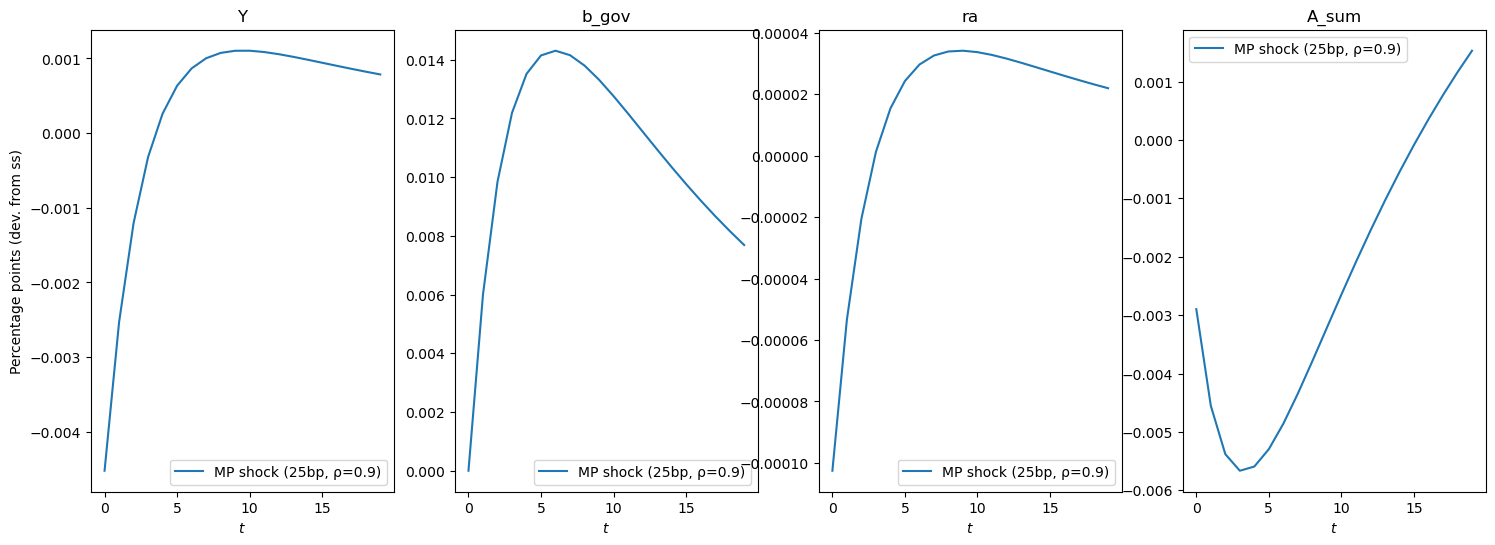

In [ ]:
show_irfs([irfs_mp], ['Y', 'K', 'C', 'rb'],
          labels=['MP shock (25bp, ρ=0.9)'])